# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [532]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [557]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load/Preprocess Data

In [537]:
df = g.load_df()
df.head()

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,...,chord_id,pc,note,time,artist,workTitle,fnames,rel_paths,recording_year,label
0,1,1,0.375,3/8,9/8,3,1,3/4,NaN,1/2,...,0,8,Ab,1.375,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,Ab(b5)
1,1,1,0.375,3/8,9/8,3,1,3/4,NaN,1/2,...,0,2,D,1.375,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,Ab(b5)
2,1,1,0.375,3/8,9/8,3,1,3/4,NaN,1/2,...,0,8,Ab,1.375,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,Ab(b5)
3,2,2,0.000,0,7/8,4,1,1/4,NaN,1/4,...,2,7,G,2.000,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,g5
4,2,2,0.000,0,7/8,3,1,7/8,NaN,1/2,...,1,7,G,2.000,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,by_Alexander_Booker,2015,g5


### Plot pitch profiles by standard

In [563]:
title_grouped, ref = g.groupby_standard(df, length=3)
ref

,workTitle,count
5,All The Things You Are,4
7,Autumn Leaves,3
11,Blue Bossa,3
12,Blues By Five,4
29,Four,5
33,Giant Steps,3
46,Joy Spring,4
47,Just Friends,4
58,Oleo,3
77,Someday My Prince Will Come,3


In [583]:
subset = df[(df['workTitle'] == 'Four') | (df['workTitle'] == 'Blues By Five')]
subset = subset[subset['artist'].isin(['John Coltrane', 'Miles Davis'])]

subset = subset.groupby(['artist', 'workTitle'], as_index=False).agg(list)
subset

,artist,workTitle,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,...,midi,volta,chord_id,pc,note,time,fnames,rel_paths,recording_year,label
0,John Coltrane,Blues By Five,"[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[0.5, 0.625, 0.875, 0.0, 0.125, 0.375, 0.5, 0....","[1/2, 5/8, 7/8, 0, 1/8, 3/8, 1/2, 3/4, 7/8, 0,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1/8, 1/4, 1/8, 1/8, 1/4, 1/8, 1/4, 1/8, 1/8, ...",...,"[68, 70, 72, 72, 75, 77, 77, 80, 82, 82, 77, 8...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[8, 10, 0, 0, 3, 5, 5, 8, 10, 10, 5, 8, 7, 5, ...","[Ab, Bb, C, C, Eb, F, F, Ab, Bb, Bb, F, Ab, G,...","[2.5, 2.625, 2.875, 3.0, 3.125, 3.375, 3.5, 3....","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[Eb7, Eb7, Eb7, Bb7, Bb7, Bb7, Bb7, Bb7, Bb7, ..."
1,John Coltrane,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, ...",...,"[70, 72, 74, 70, 72, 74, 70, 72, 74, 77, 75, 7...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 0, 2, 10, 0, 2, 10, 0, 2, 5, 3, 2, 10, 0,...","[Bb, C, D, Bb, C, D, Bb, C, D, F, Eb, D, Bb, C...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[EbMaj7, EbMaj7, EbMaj7, EbMaj7, EbMaj7, EbMaj..."
2,Miles Davis,Blues By Five,"[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[0.0, 0.25, 0.5, 0.375, 0.5, 0.625, 0.75, 0.0,...","[0, 1/4, 1/2, 3/8, 1/2, 5/8, 3/4, 0, 1/4, 0, 1...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1/4, 1/4, 1/4, 1/8, 1/8, 1/8, 1/4, 1/4, 1/2, ...",...,"[70, 70, 70, 73, 74, 73, 74, 70, 70, 67, 70, 7...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 10, 10, 1, 2, 1, 2, 10, 10, 7, 10, 0, 10,...","[Bb, Bb, Bb, C#, D, C#, D, Bb, Bb, G, Bb, C, B...","[1.0, 1.25, 1.5, 2.375, 2.5, 2.625, 2.75, 3.0,...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[Bb7, Bb7, Bb7, Eb7, Eb7, Eb7, Eb7, Bb7, Bb7, ..."
3,Miles Davis,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, 1/8, ...",...,"[72, 74, 76, 72, 74, 76, 72, 74, 76, 79, 77, 7...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 2, 4, 0, 2, 4, 0, 2, 4, 7, 5, 4, 0, 2, 3, ...","[C, D, E, C, D, E, C, D, E, G, F, E, C, D, Eb,...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[FMaj7, FMaj7, FMaj7, FMaj7, FMaj7, FMaj7, FMa.

In [635]:
data = {}
songs = []
artists = []

for row in range(subset.shape[0]):
    subset_row = subset.iloc[[row]]
    worktitle = subset_row.iloc[0]['workTitle']
    
    if worktitle not in songs:
        songs.append(worktitle)
    
    
    artist = (subset_row.iloc[0]['artist'])

    if artist not in artists:
        artists.append(artist)
        
    notes = (subset_row.iloc[0]['note'])

    key = (worktitle, artist)
    data[key] = notes

print(songs, artists) 

['Blues By Five', 'Four'] ['John Coltrane', 'Miles Davis']


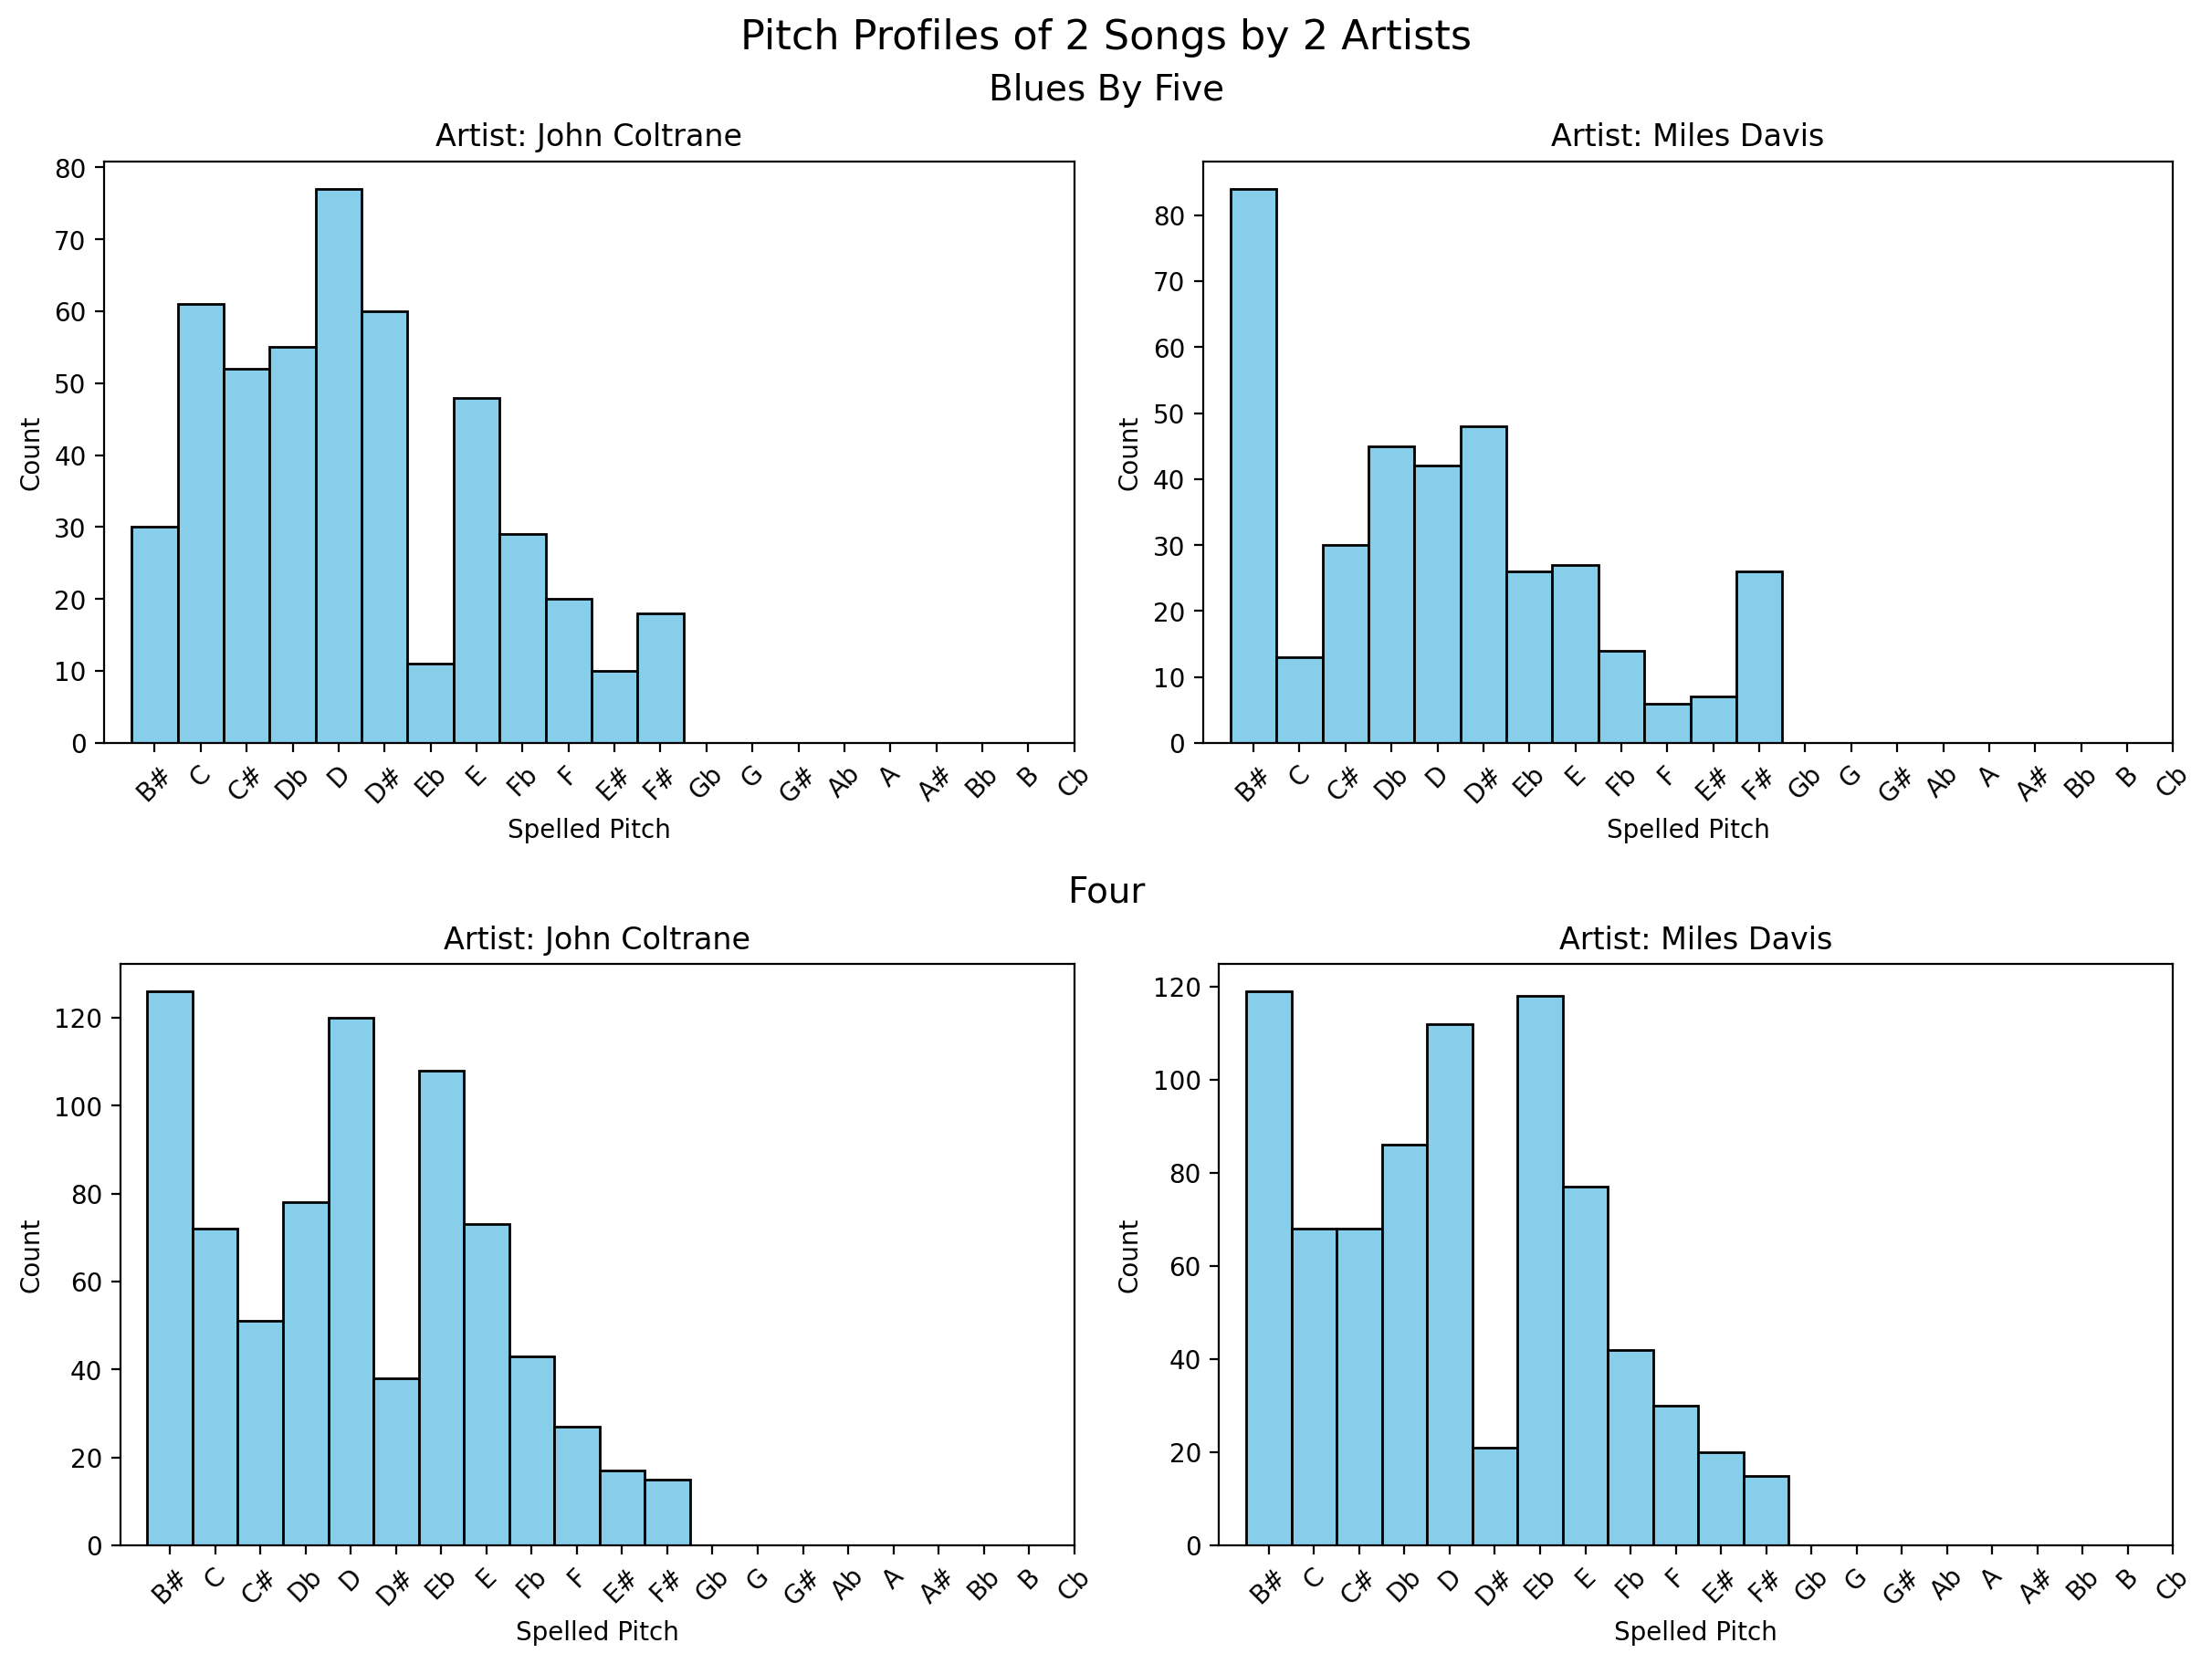

In [629]:
# --- Plot ---
fig = plt.figure(figsize=(12, 9),constrained_layout=True)
subfigs = fig.subfigures(nrows=2, ncols=1)

for i, song in enumerate(songs):
    subfig = subfigs[i]
    subfig.suptitle(f'{song}', fontsize=14)
    
    axs = subfig.subplots(nrows=1, ncols=2)
    
    for j, artist in enumerate(artists):
        ax = axs[j]
        
        # Get the pitch profile data:
        pitch_data = data[(song, artist)]
        
        # Plot histogram:
        ax.hist(pitch_data, bins=np.arange(13)-0.5, color='skyblue', edgecolor='black')
        
        # Set labels:
        ax.set_title(f'Artist: {artist}')
        ax.set_xlabel('Spelled Pitch')
        ax.set_ylabel('Count')
        
        # Use spelled pitch on x-axis:
        ax.set_xticks(np.arange(len(pitch_class_names)))
        ax.set_xticklabels(g.pitch_class_names, rotation=45)

# Global figure title:
fig.suptitle('Pitch Profiles of 2 Songs by 2 Artists', fontsize=16)

plt.show()

## Questions to ask: 
1. How do we determine the time frame of the pieces to compare
2. 
